In [118]:
import os

os.environ["OMP_NUM_THREADS"] = "4"

print(os.environ["OMP_NUM_THREADS"])
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

4


In [119]:
import seaborn as sns
from sklearn.datasets import make_blobs
#the make_blobs is used for the make the datasets for clustering
#or make_blobs make dummy datasets 
 

In [120]:
X,y=make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

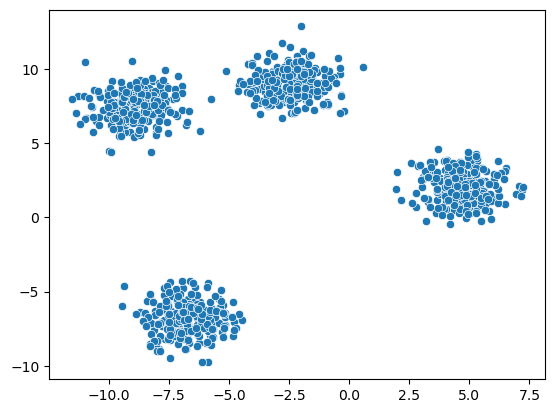

In [121]:
#visulize the data
sns.scatterplot(x=X[:,0],y=X[:,1])

Before doing the clutering we need to standarized the data beacuse it placed of distance
rember that for the clustering we always need to scale the data

this simple we generted for the particles for that we dont need to scale the data

In [122]:
#k-mean Clustering
from sklearn.cluster import KMeans

In [123]:
k=3
kmean=KMeans(
    n_clusters=k, 
    random_state=42,
    n_init=10
)
kmean

KMeans(n_clusters=3, n_init=10, random_state=42)

In [124]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

lables=kmean.fit_predict(X) 

In [125]:
lables

array([0, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 2, 2, 0,
       0, 0, 2, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 0, 1, 2, 0, 0, 2, 1, 2, 0,
       2, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 0, 0, 2, 1, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 2, 0, 1, 1,
       0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 2, 2, 0, 1, 0,
       0, 1, 2, 2, 2, 2, 1, 0, 1, 2, 0, 1, 0, 2, 0, 1, 2, 0, 1, 2, 0, 1,
       2, 0, 2, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 1,
       0, 2, 0, 2, 2, 0, 1, 0, 2, 1, 0, 0, 2, 1, 0, 1, 2, 0, 0, 2, 0, 0,
       1, 0, 1, 0, 2, 2, 0, 1, 0, 1, 2, 0, 0, 1, 2, 0, 2, 2, 0, 0, 1, 1,
       1, 0, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2,
       0, 0, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 0,
       1, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 2, 0, 2,
       0, 0, 1, 2, 0, 0, 2, 0, 2, 1, 0, 0, 2, 0, 1, 2, 0, 1, 0, 2, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

<Axes: >

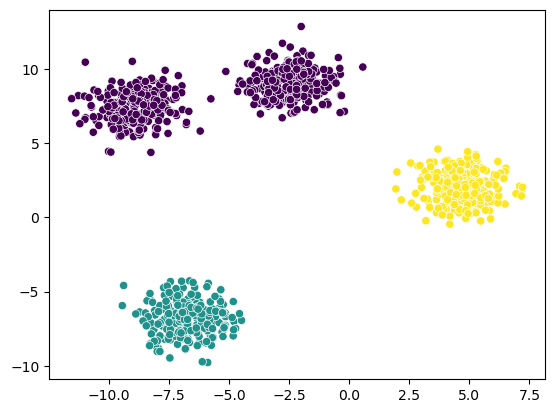

In [126]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=lables)

# choose our k value  - Elbow And Silhouette score


In [127]:
#Elbow Method
 
wcss=[]
for i in range(1, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    #in the inertia we get the all stores values for wcss

<Axes: >

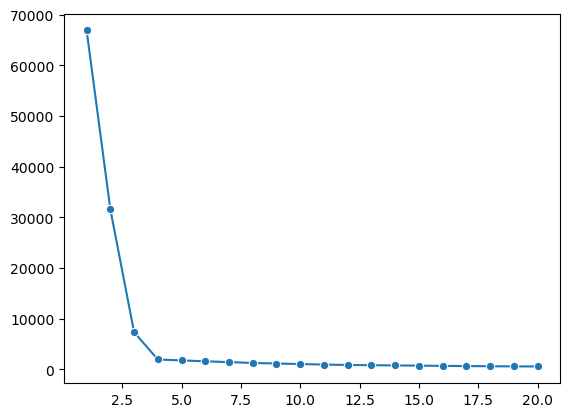

In [99]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [128]:
#kneed Module
#actuomatically find out the elbow point
!pip install kneed

In [129]:
from kneed import KneeLocator

In [130]:
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")

In [131]:
print("Optimal K = ",knee.elbow)

Optimal K =  4


# Silhouette Score

In [132]:
from sklearn.metrics import silhouette_score

In [133]:
ss=[]

for k in range (2,11):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X)
    score=silhouette_score(X,lables)

    ss.append(score)

<Axes: >

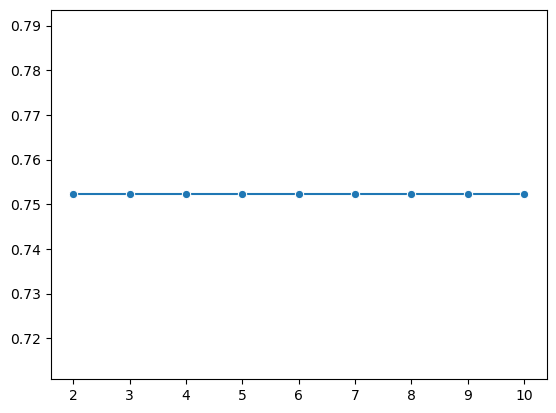

In [134]:
#plot -K & ss

sns.lineplot(x=range(2,11),y=ss,marker='o')